In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [32]:
data = pd.read_json("bm_prefill_gpu.json")

print(data["device_count"].value_counts())

data = data[data["device_count"] == 1]
data

device_count
1    576
Name: count, dtype: int64


,timestamp,time,device_count,prompt_length,max_seq_len,max_tokens,performance_mode,yield_probability,total_generated_tokens,yield_count
0,2025-09-24 12:46:16.638639212,0.507162,1,994,8192,1,False,0.942533,1,17
1,2025-09-24 12:46:20.195419550,0.543662,1,3118,8192,1,False,0.270449,1,6
2,2025-09-24 12:46:23.959748030,0.693110,1,1978,8192,1,False,0.989987,1,18
3,2025-09-24 12:46:28.041949987,0.827837,1,7969,8192,1,False,0.330685,1,9
4,2025-09-24 12:46:32.090311050,0.808531,1,8164,8192,1,False,0.384395,1,10
...,...,...,...,...,...,...,...,...,...,...
571,2025-09-24 13:22:08.709024429,0.524915,1,782,8192,1,False,0.203314,1,2
572,2025-09-24 13:22:12.354234695,0.576559,1,1762,8192,1,False,0.461794,1,9
573,2025-09-24 13:22:15.872072220,0.552967,1,1130,8192,1,False,0.482828,1,7
574,2025-09-24 13:22:19.974001408,0.849685,1,7709,8192,1,False,0.349881,1,9


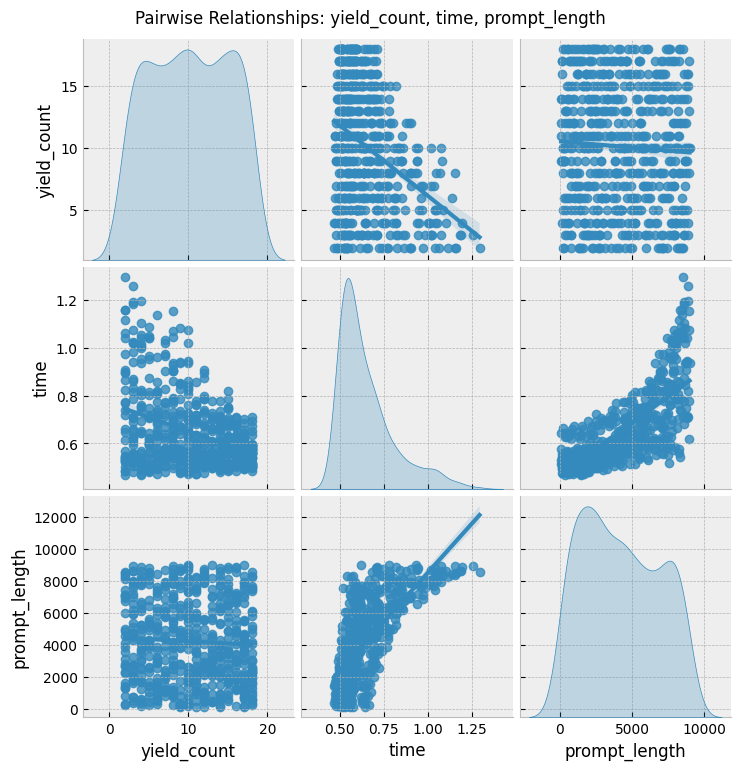

Correlation matrix:
                yield_count      time  prompt_length
yield_count       1.000000 -0.362597      -0.052823
time             -0.362597  1.000000       0.739822
prompt_length    -0.052823  0.739822       1.000000


In [33]:
import seaborn as sns

# Select relevant columns
corr_data = data[["yield_count", "time", "prompt_length"]]

# Pairplot to visualize relationships
sns.pairplot(corr_data, kind="reg", diag_kind="kde")
plt.suptitle("Pairwise Relationships: yield_count, time, prompt_length", y=1.02)
plt.show()

# Display correlation matrix
corr_matrix = corr_data.corr()
print("Correlation matrix:\n", corr_matrix)

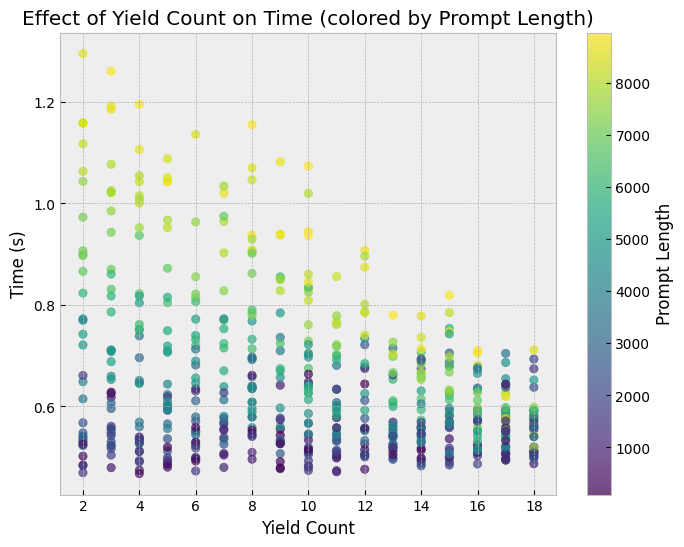

In [34]:
# Scatter plot: yield_count vs time, colored by prompt_length
plt.figure(figsize=(8, 6))
sc = plt.scatter(data["yield_count"], data["time"], c=data["prompt_length"], cmap="viridis", alpha=0.7)
plt.xlabel("Yield Count")
plt.ylabel("Time (s)")
plt.title("Effect of Yield Count on Time (colored by Prompt Length)")
cbar = plt.colorbar(sc)
cbar.set_label("Prompt Length")
plt.show()

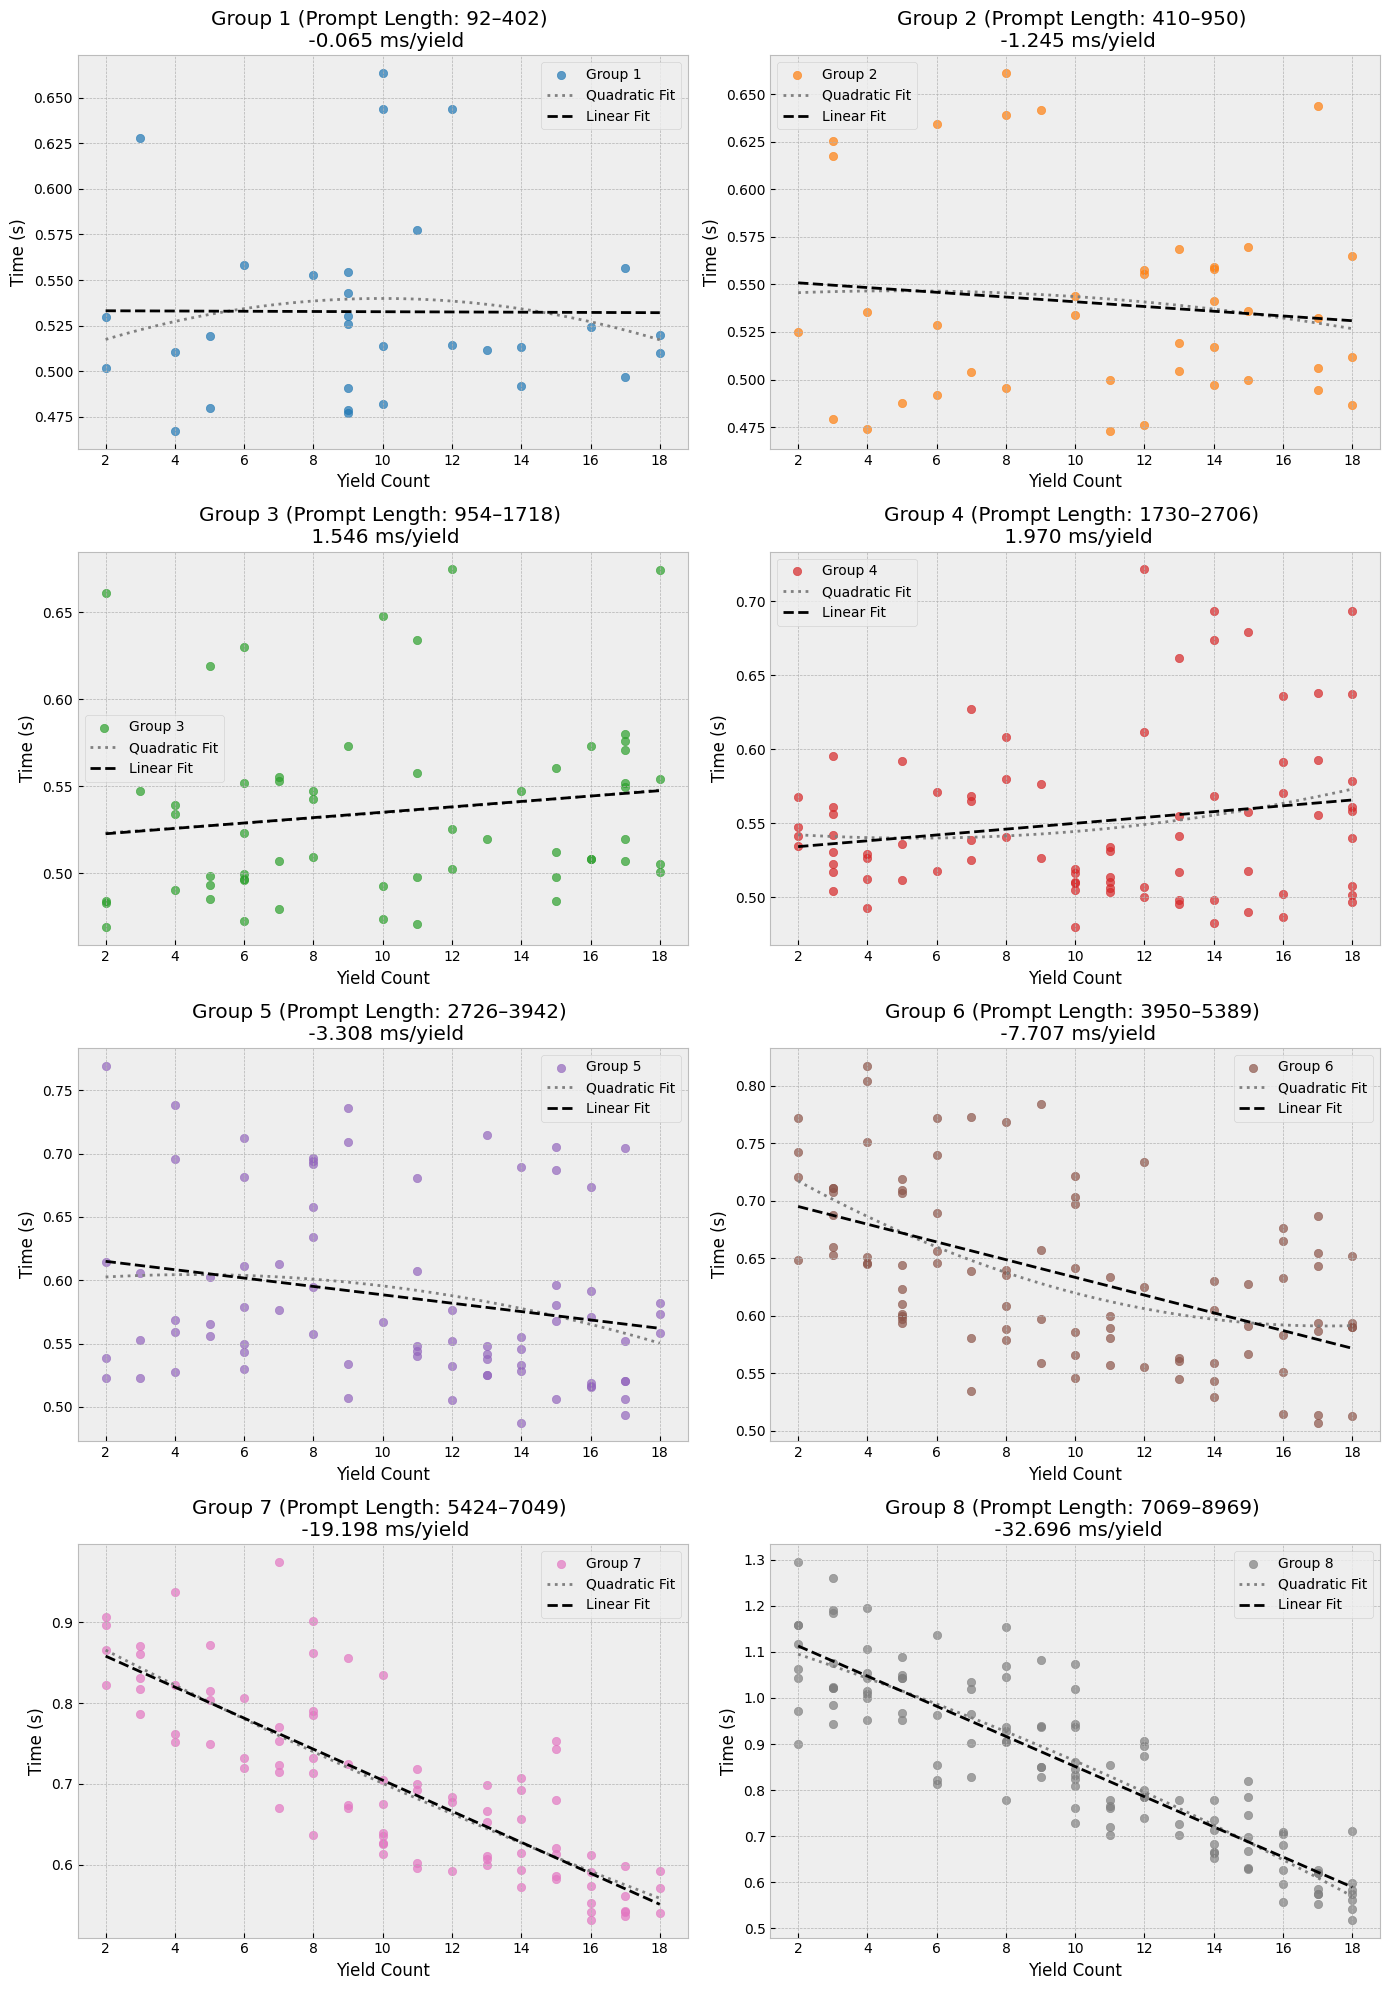

In [35]:
from scipy.optimize import curve_fit


def fit_quad(x, a, b, c):
    return a * x**2 + b * x + c


def fit_lin(x, a, b):
    return a * x + b

plt.style.use("bmh")
cmap = plt.get_cmap("tab10")

# Custom bin edges for linearly increasing group sizes
pl_min = data["prompt_length"].min()
pl_max = data["prompt_length"].max()
num_groups = 8
colors = [cmap(i % 10) for i in range(num_groups)]

# Calculate bin edges so each bin covers a linearly increasing range
edges = np.linspace(np.sqrt(pl_min), np.sqrt(pl_max), num_groups + 1)
edges = np.round(edges**2).astype(int)

data["pl_group"] = pd.cut(data["prompt_length"], bins=edges, labels=False, include_lowest=True)

fig, axes = plt.subplots(num_groups // 2, 2, figsize=(14, 5 * num_groups // 2), sharex=False, sharey=False)
axes = axes.flatten()

for group_id in range(num_groups):
    ax = axes[group_id]
    group = data[data["pl_group"] == group_id]
    x = group["yield_count"]
    y = group["time"]
    color = colors[group_id]  # pick well-separated colors
    ax.scatter(x, y, label=f"Group {group_id + 1}", color=color, alpha=0.7)
    if len(x) > 2:
        try:
            popt, _ = curve_fit(fit_quad, x, y)
            x_fit = np.linspace(x.min(), x.max(), 100)
            y_fit = fit_quad(x_fit, *popt)
            ax.plot(x_fit, y_fit, color="gray", linestyle=":", label="Quadratic Fit")

            popt_lin, _ = curve_fit(fit_lin, x, y)
            y_fit_lin = fit_lin(x_fit, *popt_lin)

            slope = f"{(popt_lin[0] * 1_000):.3f}"
            ax.plot(x_fit, y_fit_lin, color="black", linestyle="--", label="Linear Fit")
        except Exception:
            pass

    # Get prompt length range for this group
    if not group.empty:
        pl_min = group["prompt_length"].min()
        pl_max = group["prompt_length"].max()
        pl_range = f"Prompt Length: {pl_min}–{pl_max}"
    else:
        pl_range = "Prompt Length: N/A"
    ax.set_title(f"Group {group_id + 1} ({pl_range}) \n {slope} ms/yield")
    ax.set_xlabel("Yield Count")
    ax.set_ylabel("Time (s)")
    ax.legend()

plt.tight_layout()
plt.show()


In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# assume df has: time, yield_count, prompt_size
df = data.copy()
X0 = df[['yield_count']].values
X1 = df[['yield_count', 'prompt_length']].values
y  = df['time'].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_metrics(X, y):
    rmses, maes = [], []
    for train_idx, test_idx in kf.split(X):
        model = LinearRegression().fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])
        rmses.append(np.sqrt(mean_squared_error(y[test_idx], pred)))
        maes.append(mean_absolute_error(y[test_idx], pred))
    return np.mean(rmses), np.mean(maes)

rmse0, mae0 = cv_metrics(X0, y)
rmse1, mae1 = cv_metrics(X1, y)

print("Yield-only model:", rmse0, mae0)
print("Yield+prompt model:", rmse1, mae1)
print("Relative RMSE diff (%)", (rmse0 - rmse1) / rmse1 * 100)



Yield-only model: 0.14824876873214268 0.11380407878610219
Yield+prompt model: 0.09344648588390705 0.07621383701373952
Relative RMSE diff (%) 58.6456326632968
